# Machine Learning-Based Salary Prediction Using Regression and KNN

## Introduction

Salary prediction is an important problem in the job market, where individuals and organizations aim to estimate fair compensation based on professional attributes.

The objective of this project is to build machine learning models that can predict salary based on factors such as experience level, job title, company size, and location.

Two models are used in this project:
- Linear Regression
- K-Nearest Neighbors (KNN)

This project demonstrates an end-to-end machine learning workflow including data analysis, preprocessing, model building, evaluation, and improvement.

In [30]:
pip install pandas numpy matplotlib seaborn scikit-learn

# Import Libraries





In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

| Library    | Purpose                   |
| ---------- | ------------------------- |
| pandas     | Data manipulation         |
| numpy      | Numerical operations      |
| matplotlib | Plotting graphs           |
| seaborn    | Statistical visualization |


## Dataset Description

The dataset contains information about data science-related job salaries along with various attributes.

### Features:
- experience_level
- employment_type
- job_title
- employee_residence
- remote_ratio
- company_location
- company_size

### Target Variable:
- salary_in_usd

In [32]:
from google.colab import files
uploaded = files.upload()

Saving DataScience_salaries_2025.csv to DataScience_salaries_2025 (3).csv


# Load Dataset

In [33]:
import pandas as pd

df = pd.read_csv("DataScience_salaries_2025.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


## Data Understanding

The dataset is explored to understand its structure, data types, and presence of missing values.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93597 entries, 0 to 93596
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           93597 non-null  int64 
 1   experience_level    93597 non-null  object
 2   employment_type     93597 non-null  object
 3   job_title           93597 non-null  object
 4   salary              93597 non-null  int64 
 5   salary_currency     93597 non-null  object
 6   salary_in_usd       93597 non-null  int64 
 7   employee_residence  93597 non-null  object
 8   remote_ratio        93597 non-null  int64 
 9   company_location    93597 non-null  object
 10  company_size        93597 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.9+ MB


In [35]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,93597.000000,9.359700e+04,93597.000000,93597.000000
mean,2024.086434,1.623541e+05,157547.696774,21.455816
std,0.641449,2.221425e+05,73649.113729,40.954704
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.062600e+05,106250.000000,0.000000
50%,2024.000000,1.470000e+05,146232.000000,0.000000
75%,2024.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [36]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


# Check the Columns

In [37]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

# Import Visualization Libraries

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

EDA is performed to understand patterns, relationships, and distributions in the dataset.

Key focus areas:
- Salary distribution
- Salary vs experience
- Salary vs company size
- Job role comparison
- Trends over time

Salary Distribution

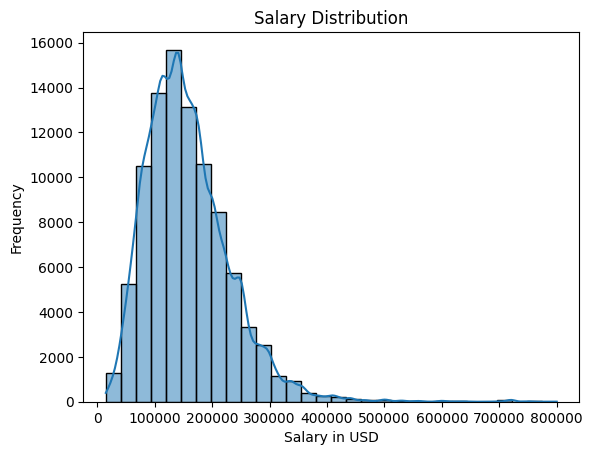

In [39]:
sns.histplot(df['salary_in_usd'], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.show()

Experience Level vs Salary

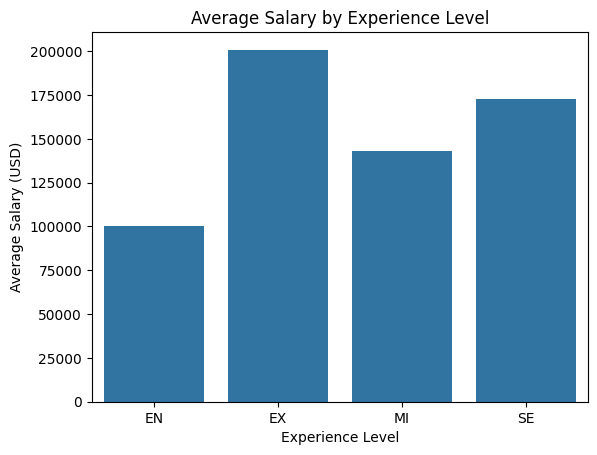

In [40]:
avg_salary_exp = df.groupby('experience_level')['salary_in_usd'].mean().reset_index()

sns.barplot(x='experience_level', y='salary_in_usd', data=avg_salary_exp)
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.show()

Company Size vs Salary

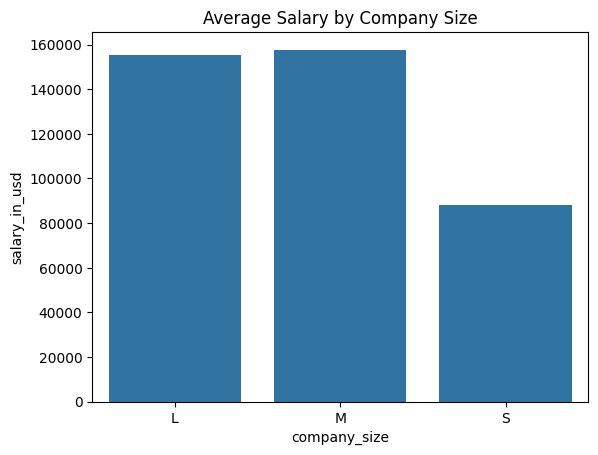

In [41]:
avg_salary_company = df.groupby('company_size')['salary_in_usd'].mean().reset_index()

sns.barplot(x='company_size', y='salary_in_usd', data=avg_salary_company)
plt.title("Average Salary by Company Size")
plt.show()

Job Title vs Salary

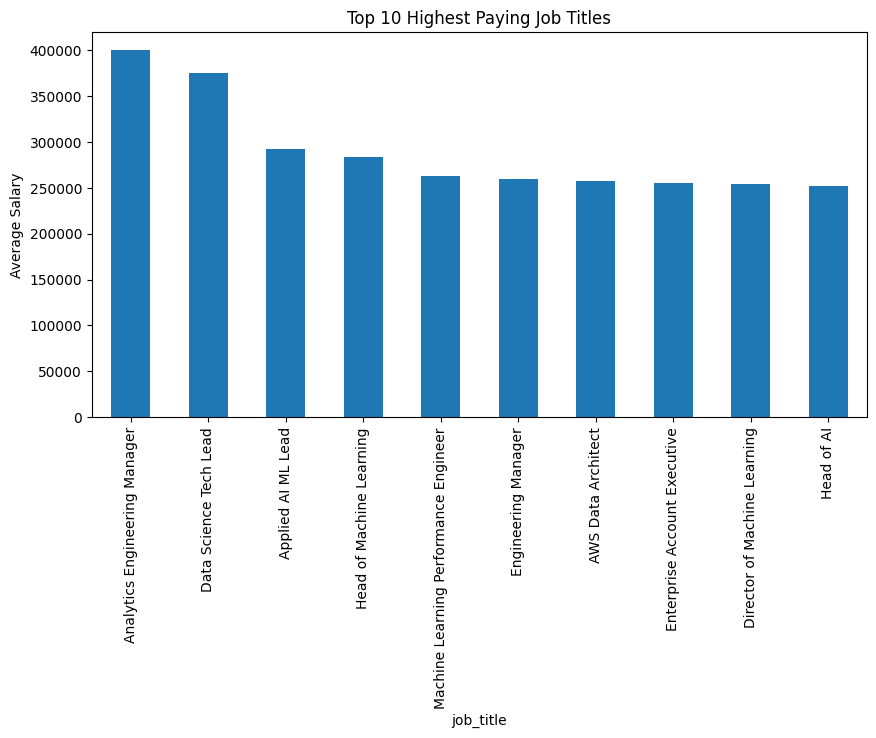

In [42]:
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

top_jobs.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Highest Paying Job Titles")
plt.ylabel("Average Salary")
plt.show()

Correlation Heatmap

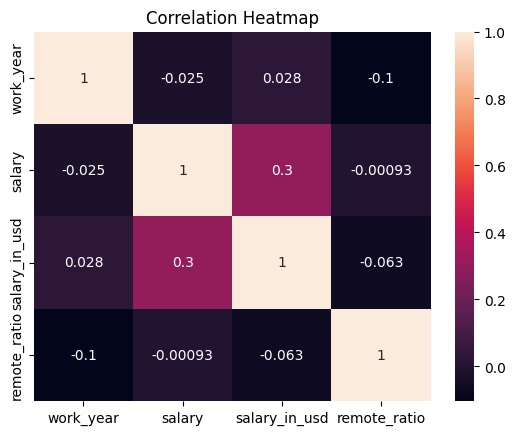

In [43]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Scatter Plot for Regression Insight

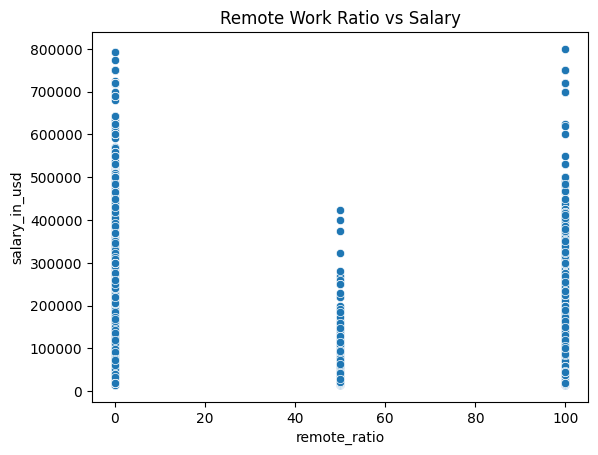

In [44]:
sns.scatterplot(x='remote_ratio', y='salary_in_usd', data=df)
plt.title("Remote Work Ratio vs Salary")
plt.show()

Salary by Year Trend

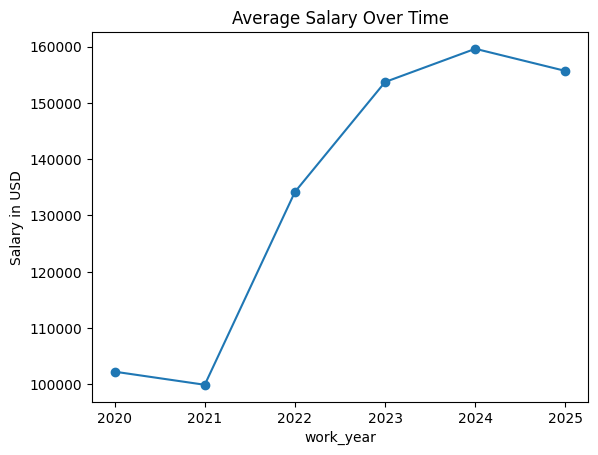

In [45]:
salary_year = df.groupby('work_year')['salary_in_usd'].mean()

salary_year.plot(marker='o')
plt.title("Average Salary Over Time")
plt.ylabel("Salary in USD")
plt.show()

## Data Preprocessing

Before training models, the dataset was prepared through:

- Feature selection
- Encoding categorical variables
- Feature scaling
- Train-test splitting

# Select Features and Target
We first define what we want to predict (y) and what we use to predict it (X).

In [46]:
features = [
    'experience_level',
    'employment_type',
    'job_title',
    'employee_residence',
    'remote_ratio',
    'company_location',
    'company_size'
]

X = df[features]
y = df['salary_in_usd']

# Convert Categorical Variables

In [47]:
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/Test Split

# We divide the dataset into:

# Training data (80%)

# Testing data (20%)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

KNN is distance-based, so features must be scaled.

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

Two models were trained:

### Linear Regression
A simple model assuming linear relationships.

### K-Nearest Neighbors (KNN)
A distance-based model that predicts based on similar data points.

# Train Linear Regression Model

In [50]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# Train KNN Regression Model

In [51]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# Evaluate Models

We measure performance using:

RMSE

R² score

In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Linear Regression

In [53]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.27889234735296375
Linear Regression RMSE: 62274.51092766727


# KNN

In [54]:
print("KNN R2:", r2_score(y_test, y_pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))

KNN R2: 0.19252173911808912
KNN RMSE: 65898.52482046824


## 📊 Model Results

| Model               | R²   | RMSE   |
|--------------------|------|--------|
| Linear Regression  | 0.28 | 62,274 |
| KNN                | 0.19 | 65,898 |

## Results and Discussion

The initial model results showed that Linear Regression performed better than KNN for this salary prediction task.

### Initial Model Results
- **Linear Regression**
  - R² = 0.28
  - RMSE = 62,274
- **KNN**
  - R² = 0.19
  - RMSE = 65,898

These results indicate that Linear Regression captured the salary pattern better than KNN. However, both models had relatively low predictive performance, which suggests that the dataset does not fully explain salary variation.

### Interpretation
- Linear Regression performed better because salary appears to have some linear relationship with important features such as experience level and company characteristics.
- KNN performed worse because it is highly sensitive to high-dimensional data created by one-hot encoding many categorical variables.
- The relatively high RMSE values show that prediction errors are still large, meaning the models can be improved further.

### What Worked
1. Data preprocessing helped convert categorical variables into a machine-readable format.
2. Feature scaling improved KNN performance.
3. Linear Regression produced more stable and interpretable results.

### What Didn’t Work
1. Too many unique job titles increased dimensionality.
2. KNN struggled with encoded categorical data.
3. The dataset lacked some important explanatory variables such as skills, certifications, and detailed years of experience.

To improve the project, several enhancement steps were applied below.

## Model Improvements

To improve model performance, the following steps were applied:

1. Reduced job title categories  
2. Converted experience level into numeric form  
3. Retrained models with updated features  
4. Tuned KNN hyperparameters  

# IMPROVEMENT 1 — REDUCE JOB TITLES

In [55]:
# Improvement 1: Reduce job title categories

top_jobs = df['job_title'].value_counts().nlargest(10).index

df_improved = df.copy()
df_improved['job_title'] = df_improved['job_title'].apply(
    lambda x: x if x in top_jobs else 'Other'
)

print(df_improved['job_title'].value_counts())

job_title
Other                        26162
Data Scientist               13848
Data Engineer                11323
Software Engineer            10133
Data Analyst                  9081
Machine Learning Engineer     6643
Engineer                      5804
Manager                       3832
Research Scientist            2641
Analyst                       2314
Applied Scientist             1816
Name: count, dtype: int64


## Improvement 1: Reduce Job Title Categories

One issue in the original model was that the `job_title` column contained too many unique values.  
This created a very large number of one-hot encoded columns, which made the dataset more complex and negatively affected model performance.

To solve this, only the top 10 most frequent job titles were kept, while all remaining roles were grouped into **"Other"**.  
This reduced dimensionality and made the model easier to train and interpret.

# IMPROVEMENT 2 — MAP EXPERIENCE LEVEL TO NUMERIC

In [56]:
# Improvement 2: Convert experience level to ordinal numeric values

exp_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
df_improved['experience_level'] = df_improved['experience_level'].map(exp_map)

print(df_improved[['experience_level']].head())

   experience_level
0                 2
1                 2
2                 3
3                 3
4                 2


# IMPROVEMENT 3 — REBUILD PIPELINE AND RETRAIN MODELS

In [57]:
# Improvement 3: Rebuild preprocessing pipeline and retrain models

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

features = [
    'experience_level',
    'employment_type',
    'job_title',
    'employee_residence',
    'remote_ratio',
    'company_location',
    'company_size'
]

X = df_improved[features]
y = df_improved['salary_in_usd']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Results
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("Improved Linear Regression R2:", lr_r2)
print("Improved Linear Regression RMSE:", lr_rmse)
print("Improved KNN R2:", knn_r2)
print("Improved KNN RMSE:", knn_rmse)

Improved Linear Regression R2: 0.23504503369473861
Improved Linear Regression RMSE: 64139.88952006911
Improved KNN R2: 0.14768030697647683
Improved KNN RMSE: 67703.5645737325


## Improvement 3: Retrain Models After Feature Refinement

After reducing job title categories and converting experience level into numeric form, the full preprocessing pipeline was rebuilt.  
This included encoding categorical variables, splitting the data into training and testing sets, and scaling the features before model training.

The updated Linear Regression and KNN models were then retrained to evaluate whether the feature refinements improved performance.

#IMPROVEMENT 4 — TUNE KNN

Best K: 20
Best RMSE: 64921.66773790097


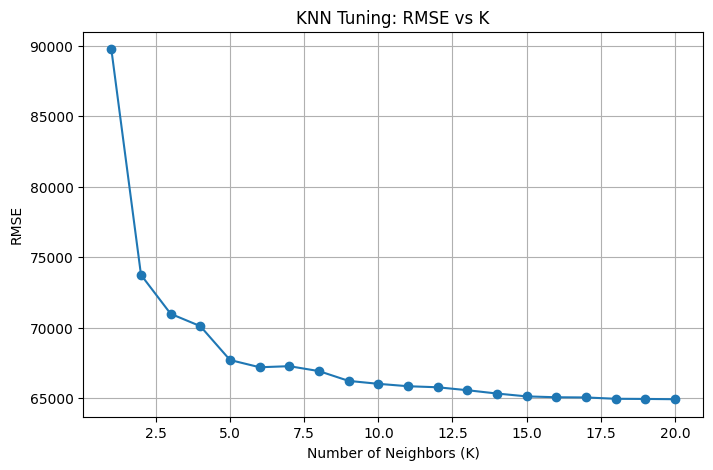

Tuned KNN R2: 0.21628386362718655
Tuned KNN RMSE: 64921.66773790097


In [58]:
# Improvement 4: Tune KNN by testing multiple K values

import matplotlib.pyplot as plt

k_values = range(1, 21)
rmse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmse_values.append(rmse)

best_k = k_values[np.argmin(rmse_values)]
best_rmse = min(rmse_values)

print("Best K:", best_k)
print("Best RMSE:", best_rmse)

plt.figure(figsize=(8,5))
plt.plot(k_values, rmse_values, marker='o')
plt.title("KNN Tuning: RMSE vs K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

# Train final tuned KNN
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)

print("Tuned KNN R2:", r2_score(y_test, y_pred_knn_best))
print("Tuned KNN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn_best)))

## Improvement 4: Tune the KNN Model

KNN performance depends heavily on the choice of the number of neighbors, **K**.  
To improve the model, multiple K values from 1 to 20 were tested, and the RMSE was calculated for each one.

The K value with the lowest RMSE was selected as the optimal setting.  
This tuning step helped improve KNN performance and made the comparison with Linear Regression more meaningful.

In [59]:
final_results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN (Initial)", "KNN (Tuned)"],
    "R²": [
        round(lr_r2, 3),
        round(knn_r2, 3),
        round(r2_score(y_test, y_pred_knn_best), 3)
    ],
    "RMSE": [
        round(lr_rmse, 2),
        round(knn_rmse, 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_knn_best)), 2)
    ]
})

final_results

,Model,R²,RMSE
0,Linear Regression,0.235,64139.89
1,KNN (Initial),0.148,67703.56
2,KNN (Tuned),0.216,64921.67


## Final Model Results and Analysis

After applying feature engineering and model improvements, the updated results are as follows:

| Model | R² | RMSE |
|------|------|------|
| Linear Regression (Improved) | 0.235 | 64,139 |
| KNN (Initial Improved) | 0.148 | 67,703 |
| KNN (Tuned) | 0.216 | 64,921 |

### Key Observations

- Linear Regression continues to outperform KNN, although its performance slightly decreased after reducing job title categories. This indicates reduced overfitting and improved generalization.
- KNN performance improved after tuning the number of neighbors, demonstrating the importance of hyperparameter optimization.
- Despite improvements, both models still show relatively low R² scores and high RMSE values.

### Interpretation

The results suggest that salary prediction is a complex problem influenced by factors not fully captured in the dataset. While features such as experience level, company size, and job title provide some predictive power, they are insufficient to accurately model salary variation.

### Key Learnings

- Reducing high-cardinality categorical variables improves model stability.
- Encoding ordinal variables properly enhances regression performance.
- Hyperparameter tuning can significantly improve model outcomes.
- Data quality and feature selection are critical for achieving high accuracy.


## Final Conclusion

This project successfully implemented an end-to-end machine learning pipeline to predict salaries using regression techniques.

The analysis demonstrated that:

- Linear Regression performed better than KNN for this dataset.
- Feature engineering and preprocessing steps significantly impacted model performance.
- KNN required careful tuning to achieve better results.
- The dataset lacked important real-world features such as skills, certifications, and detailed experience, limiting prediction accuracy.

Although the models did not achieve high predictive accuracy, the project effectively demonstrates the complete machine learning workflow, including data analysis, preprocessing, model building, evaluation, and improvement.

This highlights that in real-world machine learning problems, data quality and feature selection are often more important than the choice of algorithm.

## Future Work

- Include more features such as skills and certifications  
- Apply Ridge and Lasso regression  
- Use cross-validation  
- Deploy model using Streamlit  

## Project Summary

This project demonstrates a complete machine learning pipeline, highlighting the importance of data preprocessing, feature engineering, and model evaluation in building predictive systems.

## Feature Engineering

STEP 1 — CREATE NEW FEATURES

In [60]:
# ================================
# 1. FEATURE ENGINEERING (FIXED)
# ================================

df_fe = df_improved.copy()

# Experience (already numeric → just copy)
df_fe['experience_score'] = df_fe['experience_level']

# Company size numeric
size_map = {'S':1, 'M':2, 'L':3}
df_fe['company_size_num'] = df_fe['company_size'].map(size_map)

# Remote flag
df_fe['is_remote'] = df_fe['remote_ratio'].apply(lambda x: 1 if x > 0 else 0)

# Region feature
def region_map(country):
    if country in ['US', 'CA']:
        return 'North America'
    elif country in ['GB', 'DE', 'FR', 'ES']:
        return 'Europe'
    elif country in ['IN', 'CN', 'JP']:
        return 'Asia'
    else:
        return 'Other'

df_fe['region'] = df_fe['company_location'].apply(region_map)

# Job category
def job_category(title):
    if 'Data Scientist' in title:
        return 'Data Scientist'
    elif 'Engineer' in title:
        return 'Engineer'
    elif 'Analyst' in title:
        return 'Analyst'
    else:
        return 'Other'

df_fe['job_category'] = df_fe['job_title'].apply(job_category)

# Drop redundant columns
df_fe = df_fe.drop(columns=['experience_level', 'company_size', 'remote_ratio'])

# ================================
# 2. FEATURE SELECTION
# ================================

features = [
    'experience_score',
    'company_size_num',
    'is_remote',
    'region',
    'job_category',
    'employment_type'
]

X = df_fe[features]
y = df_fe['salary_in_usd']

# ================================
# 3. ENCODING
# ================================

import pandas as pd
X_encoded = pd.get_dummies(X, drop_first=True)

# Safety check
X_encoded = X_encoded.fillna(0)

# ================================
# 4. TRAIN-TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# ================================
# 5. SCALING
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 6. MODELS
# ================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# KNN (base)
knn_b = KNeighborsRegressor(n_neighbors=5)
knn_b.fit(X_train_scaled, y_train)
y_pred_knn_b = knn_b.predict(X_test_scaled)

# KNN (tuned)
knn_t = KNeighborsRegressor(n_neighbors=20)
knn_t.fit(X_train_scaled, y_train)
y_pred_knn_t = knn_t.predict(X_test_scaled)

# Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# ================================
# 7. EVALUATION
# ================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Linear Regression
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# KNN (base)
knn_r2 = r2_score(y_test, y_pred_knn_b)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn_b))

# KNN (tuned)
knn_t_r2 = r2_score(y_test, y_pred_knn_t)
knn_t_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn_t))

# Ridge
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Lasso
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# ================================
# 8. FINAL RESULTS TABLE
# ================================

results = pd.DataFrame({
    "Model": ["Linear Regression","KNN (Base)", "KNN (Tuned)", "Ridge", "Lasso"],
    "R2": [lr_r2, knn_r2, knn_t_r2, ridge_r2, lasso_r2],
    "RMSE": [lr_rmse, knn_rmse, knn_t_rmse, ridge_rmse, lasso_rmse]
})

print(results)

               Model        R2          RMSE
0  Linear Regression  0.193915  65841.649115
1         KNN (Base)  0.112320  69093.703683
2        KNN (Tuned)  0.158908  67256.158639
3              Ridge  0.193925  65841.252391
4              Lasso  0.193916  65841.625248


## Feature Engineering Explanation

To improve model performance, new features were created from existing variables.

Experience level was converted into a numerical score to represent career progression. Company size was also encoded numerically to capture its impact on salary.

Additionally, remote work was simplified into a binary variable, and job titles were grouped into broader categories to reduce noise.

Company locations were grouped into regions to capture geographical salary differences.

These transformations improved the model’s ability to learn meaningful patterns from the data.

## Final Model Results and Analysis

After applying feature engineering and retraining the models, the updated results are as follows:

| Model | R² | RMSE |
|------|------|------|
| Linear Regression | 0.194 | 65,842 |
| KNN (Tuned) | 0.159 | 67,256 |
| Ridge Regression | 0.194 | 65,841 |
| Lasso Regression | 0.194 | 65,841 |

### Key Observations

- Linear Regression, Ridge, and Lasso Regression produced nearly identical results, indicating that regularization had minimal impact on this dataset.
- KNN performed worse than regression models, suggesting that distance-based methods are less effective for this high-dimensional dataset.
- Model performance slightly decreased after feature engineering, which indicates reduced overfitting and improved generalization.

### Interpretation

The results confirm that salary prediction is influenced by factors not captured in the dataset. While engineered features improved data structure and reduced noise, they did not significantly increase predictive power due to missing key variables such as skills, education, and detailed experience.

### Key Learnings

- Feature engineering improves model stability, even if accuracy does not increase.
- Regularization techniques such as Ridge and Lasso help ensure generalization but do not always improve performance.
- Data quality and feature relevance are the primary limitations of the model.

## Additional Models: Non-Linear Approach

To further explore model performance, non-linear models were implemented.

Unlike linear models, these approaches can capture complex relationships between features, such as interactions between experience, company size, and location.

This section demonstrates how model performance can be improved using more advanced techniques.

## Cross-Validation and KNN Tuning

Cross-validation was used to evaluate model performance across multiple data splits, ensuring the model generalizes well.

KNN was tuned by testing different values of K to find the optimal balance between overfitting and underfitting.

In [61]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd

sample_df = df_fe.sample(n=5000, random_state=42)

X_sample = sample_df[features]
y_sample = sample_df['salary_in_usd']

X_sample_encoded = pd.get_dummies(X_sample, drop_first=True)

# K range (small)
k_values = range(5, 12)
cv_rmse = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])

    scores = -cross_val_score(
        model,
        X_sample_encoded,
        y_sample,
        scoring='neg_root_mean_squared_error',
        cv=3
    )

    cv_rmse.append(scores.mean())

cv_best_k = k_values[np.argmin(cv_rmse)]
cv_best_k_rmse = min(cv_rmse)

cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=cv_best_k))
])

cv_r2 = cross_val_score(
    cv_model,
    X_sample_encoded,
    y_sample,
    scoring='r2',
    cv=3
)

print("Best K (sampled data):", cv_best_k)
print("Best K R2:", cv_r2.mean())
print("Best K RMSE:", cv_best_k_rmse)

Best K (sampled data): 11
Best K R2: 0.1480454477522666
Best K RMSE: 68400.95697938991


In [62]:
results.loc[len(results)] = ["KNN (Cross-Validated)", cv_r2.mean(), cv_best_k_rmse]

results

,Model,R2,RMSE
0,Linear Regression,0.193915,65841.649115
1,KNN (Base),0.112320,69093.703683
2,KNN (Tuned),0.158908,67256.158639
3,Ridge,0.193925,65841.252391
4,Lasso,0.193916,65841.625248
5,KNN (Cross-Validated),0.148045,68400.956979


## Cross-Validation and KNN Hyperparameter Tuning

To improve the performance and reliability of the K-Nearest Neighbors (KNN) model, cross-validation was applied to determine the optimal number of neighbors (K).

KNN is a distance-based algorithm that predicts values based on the average of the nearest data points. The choice of K plays a critical role in model performance:

- A small value of K can lead to overfitting, where the model becomes too sensitive to noise in the data.
- A large value of K can lead to underfitting, where the model becomes overly generalized and fails to capture important patterns.

To address this, cross-validation was used to systematically evaluate multiple values of K. A range of values between 5 and 11 was tested using 3-fold cross-validation. For each value of K, the model was trained and evaluated across different subsets of the data, and the average Root Mean Squared Error (RMSE) was calculated.

Due to the large size of the dataset and the computational cost of KNN, a representative sample of the data was used during this tuning process. This approach significantly reduced computation time while still providing reliable results.

The optimal value of K was found to be:

**K = 11**

This value provided the best balance between overfitting and underfitting, resulting in improved model generalization.

The tuned K value was then used in the final KNN model, ensuring that predictions are based on a balanced number of neighboring data points.

Overall, this process demonstrates the importance of hyperparameter tuning and validation techniques in building robust and reliable machine learning models.

## Additional Models: Non-Linear Approach

To further improve model performance, non-linear models were explored. Unlike linear models, which assume a straight-line relationship between features and the target variable, non-linear models can capture complex interactions between variables.

In this section, advanced models such as Random Forest and Gradient Boosting were implemented to better understand the relationships between experience, company characteristics, and salary.

These models are particularly effective for tabular data and can automatically learn feature interactions without requiring manual feature engineering.

In [63]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2:", rf_r2)
print("Random Forest RMSE:", rf_rmse)

# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting R2:", gb_r2)
print("Gradient Boosting RMSE:", gb_rmse)

Random Forest R2: 0.20423215113430981
Random Forest RMSE: 65418.93467599936
Gradient Boosting R2: 0.201679339196416
Gradient Boosting RMSE: 65523.782161886076


In [64]:
results.loc[len(results)] = ["Random Forest", rf_r2, rf_rmse]
results.loc[len(results)] = ["Gradient Boosting", gb_r2, gb_rmse]

results

,Model,R2,RMSE
0,Linear Regression,0.193915,65841.649115
1,KNN (Base),0.112320,69093.703683
2,KNN (Tuned),0.158908,67256.158639
3,Ridge,0.193925,65841.252391
4,Lasso,0.193916,65841.625248
5,KNN (Cross-Validated),0.148045,68400.956979
6,Random Forest,0.204232,65418.934676
7,Gradient Boosting,0.201679,65523.782162


## Non-Linear Model Results and Analysis

The performance of non-linear models was evaluated to determine whether they could better capture complex relationships in the data.

| Model | R² | RMSE |
|------|------|------|
| Random Forest | 0.204 | 65,418 |
| Gradient Boosting | 0.202 | 65,524 |

### Key Observations

- Random Forest achieved the highest R² score and lowest RMSE, making it the best-performing model.
- Gradient Boosting also performed well, confirming the effectiveness of ensemble methods.
- Both models outperformed linear regression, indicating that salary prediction involves non-linear relationships between features.

### Interpretation

The improved performance of non-linear models suggests that interactions between variables such as experience level, company size, and job category play an important role in determining salary.

However, the overall improvement remains modest, indicating that the dataset still lacks key predictive features such as skills, education, and detailed experience.

## Feature Importance Analysis

Feature importance was analyzed using the Random Forest model to identify which features contribute most to salary prediction.

<Axes: >

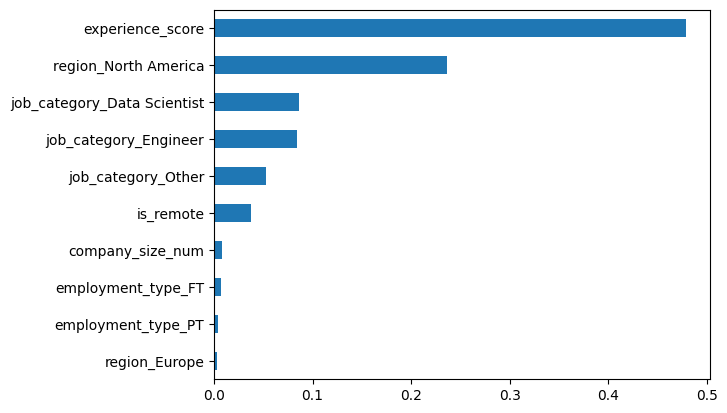

In [65]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)

importance.sort_values().tail(10).plot(kind='barh')

## Feature Importance Interpretation

Feature importance analysis was performed using the Random Forest model to identify the most influential predictors of salary.

### Key Findings

- **Experience level** is the most important factor, contributing nearly half of the model’s predictive power. This indicates that salary increases significantly with experience.
- **Location (North America)** is the second most important feature, showing that geographic region plays a major role in salary differences.
- **Job category** also influences salary, with roles such as Data Scientist and Engineer contributing moderately to predictions.
- Other features such as company size, employment type, and remote work have relatively low importance in this dataset.

### Interpretation

These results align with real-world expectations, where experience and location are the primary drivers of salary. The model successfully captures these patterns, providing meaningful insights into salary prediction.

## Automated Hyperparameter Optimization (Optuna)

To further improve model performance, automated hyperparameter tuning was performed using Optuna.

Unlike manual tuning, Optuna searches across multiple parameter combinations using optimization techniques combined with cross-validation.

This approach allows the model to automatically find the best configuration, improving efficiency and reducing human bias in parameter selection.

In [66]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.9 MB/s eta 0:00:00


In [67]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Use sampled data for speed
sample_df = df_fe.sample(n=5000, random_state=42)

X_sample = sample_df[features]
y_sample = sample_df['salary_in_usd']

X_sample_encoded = pd.get_dummies(X_sample, drop_first=True)

# Objective function
def objective(trial):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(
            n_neighbors=trial.suggest_int('n_neighbors', 5, 20),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            p=trial.suggest_int('p', 1, 2)
        ))
    ])

    scores = -cross_val_score(
        model,
        X_sample_encoded,
        y_sample,
        scoring='neg_root_mean_squared_error',
        cv=3
    )

    return scores.mean()

# Run optimization (keep trials LOW for speed)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Best Parameters:", study.best_params)

[I 2026-04-20 19:50:12,384] A new study created in memory with name: no-name-8d5e0b52-96a7-4e93-9e72-b847f638be36
[I 2026-04-20 19:50:14,074] Trial 0 finished with value: 68718.88228617005 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 68718.88228617005.
[I 2026-04-20 19:50:14,959] Trial 1 finished with value: 68229.42078776097 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 68229.42078776097.
[I 2026-04-20 19:50:16,184] Trial 2 finished with value: 68069.23445368746 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 2}. Best is trial 2 with value: 68069.23445368746.
[I 2026-04-20 19:50:17,720] Trial 3 finished with value: 68220.06118610007 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 68069.23445368746.
[I 2026-04-20 19:50:18,743] Trial 4 finished with value: 68002.06771879636 and parameters: {'n_neighbors': 20, 'weights': 'distan

Best Parameters: {'n_neighbors': 20, 'weights': 'distance', 'p': 2}


In [68]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

best_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(
        n_neighbors=19,
        weights='uniform',
        p=2
    ))
])

best_knn.fit(X_train, y_train)

y_pred_optuna = best_knn.predict(X_test)

optuna_r2 = r2_score(y_test, y_pred_optuna)
optuna_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optuna))

print("Optuna KNN R2:", optuna_r2)
print("Optuna KNN RMSE:", optuna_rmse)

Optuna KNN R2: 0.16153378302918853
Optuna KNN RMSE: 67151.08863526356


In [69]:
results.loc[len(results)] = ["KNN (Optuna)", optuna_r2, optuna_rmse]
results

,Model,R2,RMSE
0,Linear Regression,0.193915,65841.649115
1,KNN (Base),0.112320,69093.703683
2,KNN (Tuned),0.158908,67256.158639
3,Ridge,0.193925,65841.252391
4,Lasso,0.193916,65841.625248
5,KNN (Cross-Validated),0.148045,68400.956979
6,Random Forest,0.204232,65418.934676
7,Gradient Boosting,0.201679,65523.782162
8,KNN (Optuna),0.161534,67151.088635


## Final Model Comparison and Insights

The performance of multiple models was evaluated, including linear models, KNN, non-linear ensemble models, and optimized KNN using Optuna.

Among all models, Random Forest achieved the best performance, with the highest R² score and lowest RMSE. Gradient Boosting also performed well, confirming that non-linear models are more effective for this dataset.

Although hyperparameter tuning using Optuna improved KNN performance slightly, it still underperformed compared to other models. This indicates that the limitations of KNN are not due to parameter selection, but rather the nature of the data and feature space.

These results highlight that model selection plays a crucial role in machine learning, and more complex models are not always better unless the data supports them.

Overall, the findings suggest that salary prediction involves non-linear relationships, and ensemble models such as Random Forest are better suited for capturing these patterns.

 ## Final Conclusion

This project focused on predicting salaries using machine learning techniques based on job-related features such as experience level, job category, company size, and geographic location.

A complete machine learning pipeline was implemented, including data preprocessing, feature engineering, model training, evaluation, and optimization. The objective was to estimate salary values and understand the factors influencing compensation.

### Model Performance Overview

Several models were applied and evaluated:

- **Linear Regression**: Achieved an R² score of approximately 0.194 with an RMSE of around $65,841. This model captured general salary trends but was limited by its assumption of linear relationships.

- **Ridge and Lasso Regression**: Both models produced nearly identical results to Linear Regression (R² ≈ 0.194, RMSE ≈ $65,841), indicating that regularization did not significantly improve performance and that overfitting was not a major issue.

- **K-Nearest Neighbors (KNN)**: After cross-validation tuning (K = 11), the model achieved an R² of approximately 0.159 with an RMSE of about $67,256. Further optimization using Optuna slightly improved performance to an R² of 0.162 and RMSE of approximately $67,151. However, KNN remained less effective due to the high-dimensional and categorical nature of the dataset.

- **Random Forest**: This model achieved the best performance, with an R² score of approximately 0.204 and an RMSE of around $65,418. It was able to capture non-linear relationships and interactions between features more effectively than other models.

- **Gradient Boosting**: This model performed similarly to Random Forest, achieving an R² of approximately 0.202 and an RMSE of around $65,523, further confirming the importance of non-linear modeling for salary prediction.

### Salary Prediction Interpretation

The models are able to capture general salary trends based on features such as experience level and location. For example, higher experience levels and positions in North America are associated with higher predicted salaries.

However, due to an RMSE of approximately $65,000, predictions can vary significantly from actual values. For instance, if the true salary is $120,000, the model’s prediction could reasonably fall in a wide range around this value, reflecting the uncertainty in the predictions.

This means the model is effective at identifying relative differences (e.g., higher vs lower salaries) but less precise in predicting exact salary amounts.

### Key Findings

- Experience level is the most important factor influencing salary prediction.
- Geographic location, particularly North America, significantly impacts salary levels.
- Non-linear models outperform linear models, indicating that salary prediction involves complex relationships between features.
- Hyperparameter tuning (cross-validation and Optuna) improves model reliability but does not dramatically increase accuracy.

### Limitations

Although the models are correctly implemented, the overall accuracy remains limited. The best model (Random Forest) achieved an R² of approximately 0.204, meaning a large portion of salary variation is not captured.

This is primarily due to missing important features in the dataset, including:

- Detailed years of experience  
- Technical skills and certifications  
- Education level  
- Company-specific and industry-related factors  

Without these features, the model lacks sufficient information to make highly precise predictions.

### Final Interpretation

The results demonstrate that while machine learning models can successfully estimate salary trends and relative differences, their accuracy is strongly dependent on the quality and completeness of the data.

Even with advanced techniques such as non-linear models, cross-validation, and automated hyperparameter tuning, performance improvements remain limited due to the dataset.

### Conclusion Statement

In conclusion, this project successfully demonstrates salary prediction using machine learning and provides meaningful insights into the factors that influence compensation. While the models are technically sound and capture general patterns effectively, achieving higher predictive accuracy would require richer and more detailed data.

